In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
# Load the dataset
df = pd.read_csv('data//canada_per_capita_income.csv')

df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [3]:
df['pci'] = df['per capita income (US$)']
df.drop('per capita income (US$)', axis=1, inplace=True)
df.head(3)

,year,pci
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484


Text(0, 0.5, 'Per Capita Income(US$)')

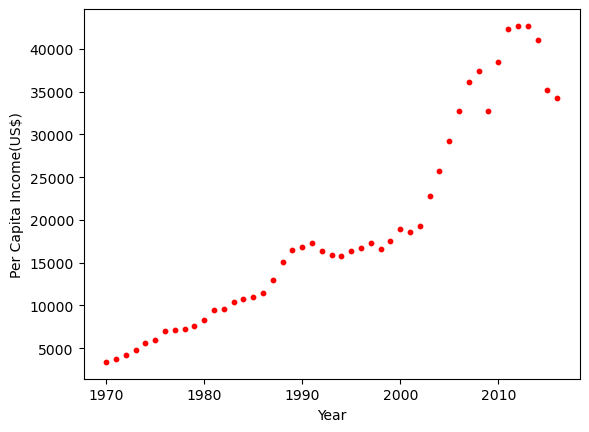

In [4]:
plt.scatter(df.year, df.pci, color='red', marker='o', s=10)
plt.xlabel('Year')
plt.ylabel('Per Capita Income(US$)')

In [5]:
lin_reg = linear_model.LinearRegression()
lin_reg.fit(df[['year']], df[['pci']])

LinearRegression()

In [6]:
year_to_predict = 2025
lin_reg.predict([[year_to_predict]])

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[45431.01947053]])

## y = mx + c

- x -> point (Year)
- y -> prediction (Per Capita Income for X-Year)
- m -> slope/gradient (coef)
- c -> y-intercept


In [7]:
lin_reg.coef_

array([[828.46507522]])

In [8]:
lin_reg.intercept_

array([-1632210.75785546])

In [9]:
# y=mx+c
(828.46507522)*(2025)+(-1632210.75785546)

45431.01946503995

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


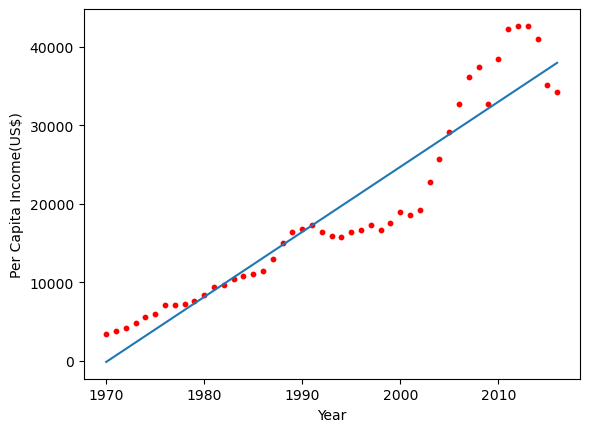

In [10]:
plt.scatter(df.year, df.pci, color='red', marker='o', s=10)
plt.xlabel('Year')
plt.ylabel('Per Capita Income(US$)')
plt.plot(df.year, lin_reg.predict(df.year.values.reshape(-1, 1)))

### Using Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df[['year']], df[['pci']], test_size=0.2, random_state=10)

In [13]:
X_train.head()

,year
45,2015
2,1972
37,2007
32,2002
10,1980


In [14]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [15]:
lin_reg.predict(X_test)

array([[28308.87945405],
       [18589.96261535],
       [33168.3378734 ],
       [31548.51840028],
       [35598.06708307],
       [16160.23340568],
       [ 2391.76788419],
       [24259.33077126],
       [ 5631.40683042],
       [ 4821.49709387]])

In [16]:
y_test

,pci
35,29198.055690
23,15875.586730
41,42334.711210
39,32755.176820
44,41039.893600
20,16838.673200
3,4804.463248
30,18987.382410
7,7100.126170
6,7062.131392


In [17]:
lin_reg.score(X_test, y_test)

0.9063173168991877